<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/13_overfitting_and_underfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overfitting and Underfitting

A neural network should learn patterns that generalize well to unseen data.

If the model is too simple, it cannot learn enough patterns. This is called **underfitting**.

If the model memorizes the training data instead of learning general patterns, it performs poorly on new data. This is called **overfitting**.

A good model maintains low loss and high accuracy on both training and validation datasets.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([
    [0],[0],[0],[1],
    [0],[0],[0],[1],
    [0],[0],[0],[1]
], dtype=float)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
small_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

small_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_small = small_model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=0
)

In [ ]:
large_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

large_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_large = large_model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    verbose=0
)

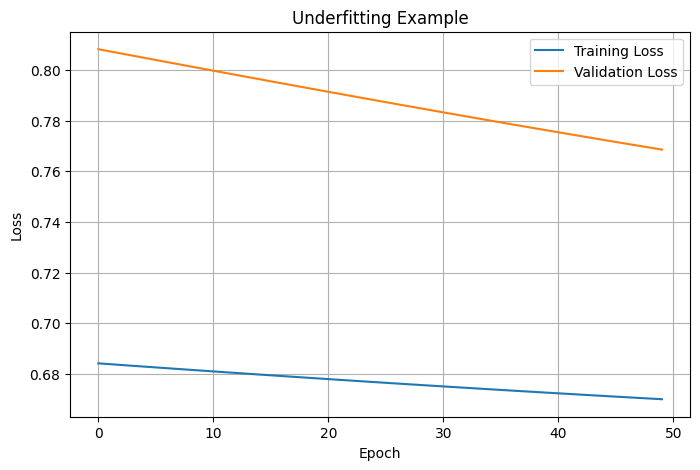

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_small.history["loss"], label="Training Loss")
plt.plot(history_small.history["val_loss"], label="Validation Loss")

plt.title("Underfitting Example")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

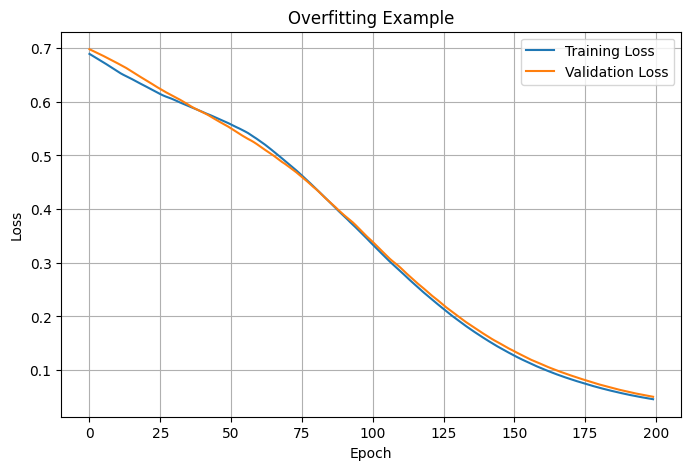

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_large.history["loss"], label="Training Loss")
plt.plot(history_large.history["val_loss"], label="Validation Loss")

plt.title("Overfitting Example")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

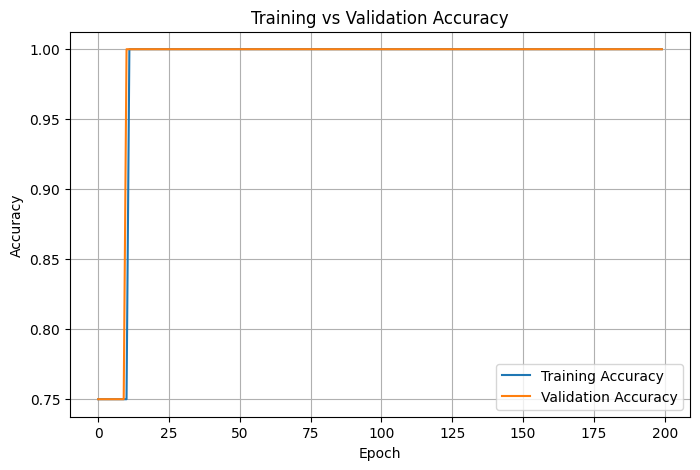

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_large.history["accuracy"], label="Training Accuracy")
plt.plot(history_large.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Condition":[
        "Underfitting",
        "Good Fit",
        "Overfitting"
    ],

    "Training Performance":[
        "Poor",
        "Good",
        "Excellent"
    ],

    "Validation Performance":[
        "Poor",
        "Good",
        "Poor"
    ]

})

comparison

,Condition,Training Performance,Validation Performance
0,Underfitting,Poor,Poor
1,Good Fit,Good,Good
2,Overfitting,Excellent,Poor
